In [1]:

# CELL 1: CONNECT TO GOOGLE DRIVE & IMPORT LIBRARIES
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

Mounted at /content/drive


In [2]:

# CELL 2: LOAD DATASET FROM DRIVE
train_path = '/content/drive/MyDrive/archive (9)/mitbih_train.csv'
test_path = '/content/drive/MyDrive/archive (9)/mitbih_test.csv'

print("Loading dataset from Google Drive...")
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
print("Data loaded successfully!\n")

Loading dataset from Google Drive...
Data loaded successfully!



--- Class Distribution in Training Set ---
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


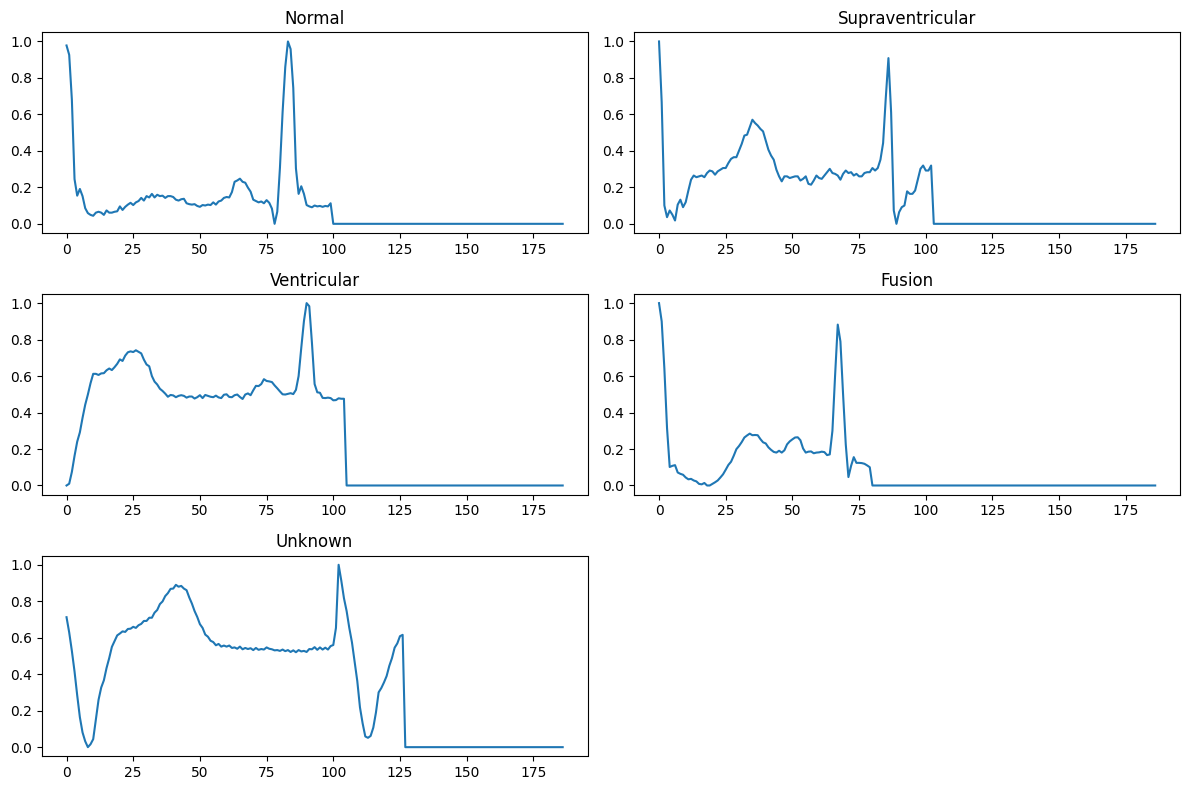

In [3]:

# CELL 3: EXPLORE DATASET (EDA)
print("--- Class Distribution in Training Set ---")
print(train_df.iloc[:, 187].value_counts())

# Plot one sample from each class
classes = {0: 'Normal', 1: 'Supraventricular', 2: 'Ventricular', 3: 'Fusion', 4: 'Unknown'}
plt.figure(figsize=(12, 8))
for i in range(5):
    plt.subplot(3, 2, i+1)
    # Get the first row of each class and plot columns 0 to 186
    sample = train_df[train_df.iloc[:, 187] == i].iloc[0, :187]
    plt.plot(sample)
    plt.title(classes[i])
plt.tight_layout()
plt.show()

In [4]:

# CELL 4: DATA PREPROCESSING
# Split into features (X) and labels (y)
X_train = train_df.iloc[:, :187].values
y_train = train_df.iloc[:, 187].values
X_test = test_df.iloc[:, :187].values
y_test = test_df.iloc[:, 187].values

# Reshape X for 1D CNN: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# One-hot encode the target labels (5 classes)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Compute class weights to handle severe data imbalance
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights_array))
print("\nComputed Class Weights to handle imbalance:", class_weights_dict)


Computed Class Weights to handle imbalance: {0: np.float64(0.24162492583240192), 1: np.float64(7.877103013945119), 2: np.float64(3.0253628196268143), 3: np.float64(27.317940717628705), 4: np.float64(2.7228735810915876)}


In [5]:

# CELL 5: BUILD ONE MACHINE LEARNING MODEL (1D CNN)
model = Sequential([
    # First Convolutional Block
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Second Convolutional Block
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Flatten and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout to prevent overfitting
    Dense(5, activation='softmax') # 5 classes output
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\n--- Model Architecture ---")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 89, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 89, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 44, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5632)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       721,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,525 (2.85 MB)

 Trainable params: 747,141 (2.85 MB)

 Non-trainable params: 384 (1.50 KB)

In [6]:

# CELL 6: MODEL TRAINING
print("\nStarting model training...")
# Training the model with class_weights applied
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights_dict
)


Starting model training...
Epoch 1/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 86s 75ms/step - accuracy: 0.9922 - loss: 0.0092 - val_accuracy: 0.1387 - val_loss: 85.8719
Epoch 2/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 76s 69ms/step - accuracy: 0.9999 - loss: 3.7848e-04 - val_accuracy: 0.1387 - val_loss: 278.9941
Epoch 3/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 1.0000 - loss: 1.8009e-05 - val_accuracy: 0.1387 - val_loss: 270.0081
Epoch 4/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 74s 68ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.1387 - val_loss: 272.2940
Epoch 5/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 74s 68ms/step - accuracy: 1.0000 - loss: 3.7304e-07 - val_accuracy: 0.1387 - val_loss: 147.7988
Epoch 6/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 84s 70ms/step - accuracy: 1.0000 - loss: 2.2772e-04 - val_accuracy: 0.1387 - val_loss: 342.4888
Epoch 7/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 74s 68ms/step - accuracy: 1.0000 - loss: 6.4835e-08 - val_accuracy: 0.1387 - val_loss: 378.5763
Epoch 8/10


In [7]:

# CELL 7: COMPARE RESULTS WITH ORIGINAL PAPER
print("\n--- Final Evaluation ---")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(f"\nOverall Test Accuracy: {accuracy_score(y_test, y_pred_classes)*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=list(classes.values())))


--- Final Evaluation ---
685/685 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step

Overall Test Accuracy: 82.76%

Detailed Classification Report:
                  precision    recall  f1-score   support

          Normal       0.83      1.00      0.91     18118
Supraventricular       0.00      0.00      0.00       556
     Ventricular       0.00      0.00      0.00      1448
          Fusion       0.00      0.00      0.00       162
         Unknown       0.00      0.00      0.00      1608

        accuracy                           0.83     21892
       macro avg       0.17      0.20      0.18     21892
    weighted avg       0.68      0.83      0.75     21892



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
